In [1]:
import numpy as np
import pandas as pd
import rpy2
from rpy2.robjects import r

# import anndata2ri
# anndata2ri.activate()

import matplotlib as mpl
import scanpy as sc

%load_ext rpy2.ipython

In [2]:
%%R
library(devtools)

Loading required package: usethis


In [3]:
%%R
devtools::load_all("scDECAF/")

ℹ Loading scDECAF


In [4]:
%%R
library(SingleCellExperiment)

Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges, ro

### Load pre-computed Drug2Cell scores in HEOCA-Lung and HLCA

In [5]:
%%R
load('20240626_d2c_heoca.RData')

# load HLCA data
load('heoca_20240626/20240626_d2c_hlca_dwn2frc60.RData')

In [6]:
%%R
# subset on lung data and subset on cell types found in both tissue and organoid ? 
adata = adata[,colData(adata)$tissue == "lung"]

hlca_adata$ann_level_4 <- droplevels(hlca_adata$ann_level_4)
adata$level_2 <- droplevels(adata$level_2)

In [7]:
%%R

hlca_adata$ann_level_4 <- as.character(hlca_adata$ann_level_4)

hlca_adata$ann_level_4[hlca_adata$ann_level_3 == 'AT1']= 'AT1'
hlca_adata$ann_level_4[hlca_adata$ann_level_3 == 'AT2']= 'AT2'

In [8]:
%%R

# should scoring be w.r.t major cell types, or all cell types? 
# going from tissue to organoid
named_vec = c('AT1' = 'alveolar type 1 (AT1) cells',
    'AT2' = 'alveolar type 2 (AT2) cells',
    'Basal resting' = 'basal cells',
    'Goblet'= 'goblet cells',
    'Neuroendocrine'= 'neuroendocrine cells',
    'Club'= 'club cells',
     'Multiciliated' = 'ciliated cells')



In [9]:
%%R

x <- assay(adata, 'X')
x[1:10,1:10]

cell_embedding <- reducedDim(adata, "UMAP")

# transpose the data before conversion to standard matrices
x <- scale(x)
x <- t(x)

### Screen Drug2Cell drug signatures in HEOCA

In [11]:
%%R
selected_gs_organoid <- pruneDrug2CellScores(data = x, embedding = cell_embedding, lambda = exp(-2), trace.it=1)

Fitting penalized multi-response gaussian GLM with alpha 0.135
Returning selected genesets with non-zero regression coefficients


#### Visualize some of the selected pathways

In [13]:
%%R 

library(ggplot2)
library(reshape2)

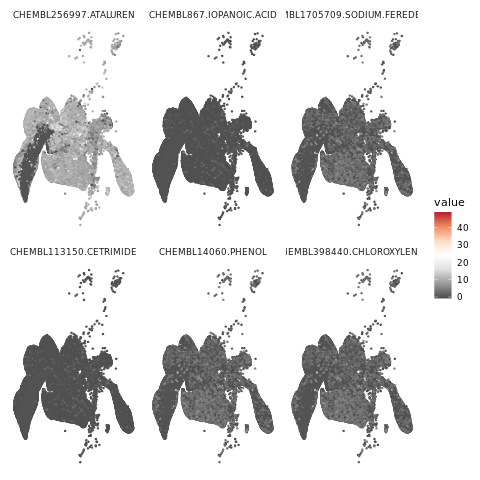

In [18]:
%%R

adata <- adata[,adata$level_2 %in% named_vec]
x <- assay(adata, 'X')
cell_embedding <- reducedDim(adata, "UMAP")
x <- scale(x)
x <- t(x)

ggdat <- melt(cbind(data.frame(x[,selected_gs_organoid[1:6]]), cell_embedding), id.vars = c('1','2'))
colnames(ggdat)[1:2] <- paste0('umap',colnames(ggdat)[1:2])

ggplot(ggdat, aes(x=umap1, y = umap2, color = value, group=variable)) + 
geom_point(size =0.5) + facet_wrap(.~variable, scales = 'free') +
theme_minimal() + theme(panel.border = element_blank(), panel.grid.major = element_blank(),
panel.grid.minor = element_blank(), axis.line = element_blank(), axis.text.x=element_blank(), 
axis.title.x=element_blank(), axis.title.y=element_blank(),
axis.text.y=element_blank()) + scale_color_distiller(palette="RdGy")



In [19]:
%%R
median_scores = matrixStats::colMedians(x)
ct = colData(adata)$level_2
ct = droplevels(ct)
xsplit = split(data.frame(x[,selected_gs_organoid]), as.factor(ct))

In [20]:
%%R
length(xsplit)

[1] 7


In [21]:
%%R
dim(xsplit[[1]])

[1] 28271   338


In [22]:
%%R

reslist <- lapply(xsplit, 
      FUN = function(x) apply(x, 2, FUN = function(y) mean(y > median_scores))
           
)

In addition: There were 50 or more warnings (use warnings() to see the first 50)


In [23]:
%%R
res_mat <- do.call(cbind, reslist)
m <- matrix(0, nrow = nrow(res_mat), ncol = ncol(res_mat), dimnames = dimnames(res_mat))
cutoff <- 0.8
m[res_mat>=cutoff] = 1


In [24]:
%%R
dim(m)

[1] 338   7


### Screen Drug2Cell drug signatures in HLCA

In [25]:
%%R
x <- assay(hlca_adata, 'X')
x[1:10,1:10]

cell_embedding <- reducedDim(hlca_adata, "UMAP")

# transpose the data before conversion to standard matrices
x <- scale(x)
x <- t(x)

In [27]:
%%R
selected_gs_tissue <- pruneDrug2CellScores(data = x, embedding = cell_embedding, lambda = exp(-2), trace.it=1)

Fitting penalized multi-response gaussian GLM with alpha 0.135
Returning selected genesets with non-zero regression coefficients


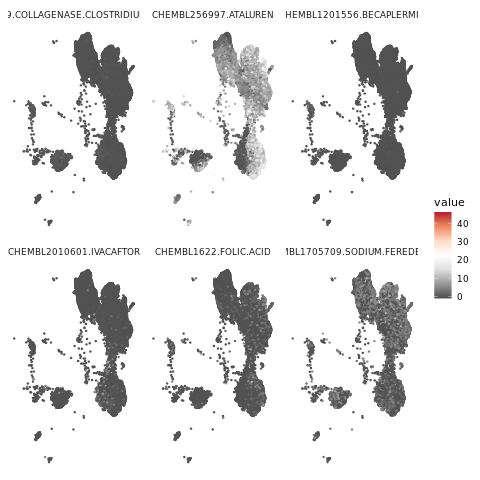

In [28]:
%%R

hlca_adata <- hlca_adata[, hlca_adata$ann_level_4 %in% names(named_vec)]
x <- assay(hlca_adata, 'X')
cell_embedding <- reducedDim(hlca_adata, "UMAP")
x <- scale(x)
x <- t(x)


ggdat <- melt(cbind(data.frame(x[,selected_gs_tissue[1:6]]), cell_embedding), id.vars = c('1','2'))
colnames(ggdat)[1:2] <- paste0('umap',colnames(ggdat)[1:2])

ggplot(ggdat, aes(x=umap1, y = umap2, color = value, group=variable)) + 
geom_point(size =0.5) + facet_wrap(.~variable, scales = 'free') +
theme_minimal() + theme(panel.border = element_blank(), panel.grid.major = element_blank(),
panel.grid.minor = element_blank(), axis.line = element_blank(), axis.text.x=element_blank(), 
axis.title.x=element_blank(), axis.title.y=element_blank(),
axis.text.y=element_blank()) + scale_color_distiller(palette="RdGy")


In [29]:
%%R
median_scores = matrixStats::colMedians(x)
ct = colData(hlca_adata)$ann_level_4
xsplit = split(data.frame(x[,selected_gs_tissue]), as.factor(ct))

In [30]:
%%R

reslist_hlca <- lapply(xsplit, 
      FUN = function(x) apply(x, 2, FUN = function(y) mean(y > median_scores))
           
)


res_mat_hlca <- do.call(cbind, reslist_hlca)
m_hlca <- matrix(0, nrow = nrow(res_mat_hlca), ncol = ncol(res_mat_hlca), dimnames = dimnames(res_mat_hlca))
m_hlca[res_mat_hlca>=cutoff] = 1


In addition: There were 50 or more warnings (use warnings() to see the first 50)


In [31]:
%%R
dim(m_hlca)

[1] 290   7


In [32]:
%%R
colnames(m_hlca) <- named_vec[colnames(m_hlca)]
m_hlca <- m_hlca[,colnames(m)]

In [33]:
%%R
print(colnames(m))
print(colnames(m_hlca))

[1] "alveolar type 1 (AT1) cells" "alveolar type 2 (AT2) cells"
[3] "basal cells"                 "ciliated cells"             
[5] "club cells"                  "goblet cells"               
[7] "neuroendocrine cells"       
[1] "alveolar type 1 (AT1) cells" "alveolar type 2 (AT2) cells"
[3] "basal cells"                 "ciliated cells"             
[5] "club cells"                  "goblet cells"               
[7] "neuroendocrine cells"       


In [34]:
%%R
# install.packages('UpSetR')
library(UpSetR)

In [35]:
%%R
colnames(m) <- paste0(colnames(m), ' (lung organoid)')
colnames(m_hlca) <- paste0(colnames(m_hlca), ' (lung tissue)')

In [37]:
%%R
length(apply(m,2, FUN=function(x) rownames(m)[x==1]))

[1] 7


In [38]:
%%R
length(apply(m_hlca, 2,  FUN=function(x) rownames(m_hlca)[x==1]))

[1] 7


In [40]:
%%R
input_list <- c(apply(m,2, FUN=function(x) rownames(m)[x==1]),
               apply(m_hlca, 2,  FUN=function(x) rownames(m_hlca)[x==1]))

In [41]:
%%R
print(length(input_list))
print(names(input_list))

[1] 14
 [1] "alveolar type 1 (AT1) cells (lung organoid)"
 [2] "alveolar type 2 (AT2) cells (lung organoid)"
 [3] "basal cells (lung organoid)"                
 [4] "ciliated cells (lung organoid)"             
 [5] "club cells (lung organoid)"                 
 [6] "goblet cells (lung organoid)"               
 [7] "neuroendocrine cells (lung organoid)"       
 [8] "alveolar type 1 (AT1) cells (lung tissue)"  
 [9] "alveolar type 2 (AT2) cells (lung tissue)"  
[10] "basal cells (lung tissue)"                  
[11] "ciliated cells (lung tissue)"               
[12] "club cells (lung tissue)"                   
[13] "goblet cells (lung tissue)"                 
[14] "neuroendocrine cells (lung tissue)"         


In [42]:
# %%R
# save(input_list, file='upsetr_plot_input.RData')

One can define "potentials" as cosine similarity of m and m_hlca, or Shannon Diversity index

In [43]:
%%R
print(dim(m))
print(dim(m_hlca))

[1] 338   7
[1] 290   7


In [44]:
%%R

# merge datasets
common_terms = intersect(rownames(m), rownames(m_hlca))
length(common_terms)

[1] 140


In [45]:
%%R
m <- m[common_terms,]
m_hlca <- m_hlca[common_terms,]

In [46]:
# %%R
# install.packages('lsa')

### Compute cosine similarity in drug target activity profiles between Organoid (HEOCA) and tissue lung (HLCA) in common cell types

In [47]:
%%R
cosinSims = list()
for (i in seq_len(ncol(m))){
    cosinSims[[i]] <- lsa::cosine(m[,i], m_hlca[,i])
}


In [48]:
%%R
# between celltype-pair similarities
names(cosinSims) <- colnames(m)
cosinSims

$`alveolar type 1 (AT1) cells (lung organoid)`
          [,1]
[1,] 0.1363636

$`alveolar type 2 (AT2) cells (lung organoid)`
          [,1]
[1,] 0.7745967

$`basal cells (lung organoid)`
          [,1]
[1,] 0.7542472

$`ciliated cells (lung organoid)`
          [,1]
[1,] 0.5685352

$`club cells (lung organoid)`
          [,1]
[1,] 0.5512459

$`goblet cells (lung organoid)`
        [,1]
[1,] 0.39036

$`neuroendocrine cells (lung organoid)`
          [,1]
[1,] 0.6299408



In [49]:
%%R
ct_labels <- gsub(" \\(lung organoid\\)", "", names(cosinSims))

In [50]:
%%R
ct_labels

[1] "alveolar type 1 (AT1) cells" "alveolar type 2 (AT2) cells"
[3] "basal cells"                 "ciliated cells"             
[5] "club cells"                  "goblet cells"               
[7] "neuroendocrine cells"       


In [51]:
%%R
cosinedata <- data.frame(cosinSims)
colnames(cosinedata) <- ct_labels

In [61]:
%%R
cosinedata

  alveolar type 1 (AT1) cells alveolar type 2 (AT2) cells basal cells
1                   0.1363636                   0.7745967   0.7542472
  ciliated cells club cells goblet cells neuroendocrine cells
1      0.5685352  0.5512459      0.39036            0.6299408


In [53]:
%%R
ct_sims <- unlist(cosinSims)
names(ct_sims) <- ct_labels

In [54]:
%%R
ct_sims

alveolar type 1 (AT1) cells alveolar type 2 (AT2) cells 
                  0.1363636                   0.7745967 
                basal cells              ciliated cells 
                  0.7542472                   0.5685352 
                 club cells                goblet cells 
                  0.5512459                   0.3903600 
       neuroendocrine cells 
                  0.6299408 


In [62]:
%%R
levels(adata$level_2)

 [1] "BEST4+ epithelial"                 "Interstitial cells of Cajal (ICC)"
 [3] "Microfold cells"                   "acinar cells"                     
 [5] "airway secretory cells"            "alpha cells"                      
 [7] "alveolar type 1 (AT1) cells"       "alveolar type 2 (AT2) cells"      
 [9] "arterial"                          "basal cells"                      
[11] "beta cells"                        "biliary cells"                    
[13] "capillary"                         "cardiovascular cells"             
[15] "central endothelial"               "chief cells"                      
[17] "ciliated cells"                    "club cells"                       
[19] "colonocytes"                       "cycling endothelial cells"        
[21] "cycling stromal cells"             "delta cells"                      
[23] "ductal cells"                      "enterocytes"                      
[25] "enteroendocrine cells"             "epsilon cells"                    

In [67]:
%%R
names(ct_sims)

[1] "alveolar type 1 (AT1) cells" "alveolar type 2 (AT2) cells"
[3] "basal cells"                 "ciliated cells"             
[5] "club cells"                  "goblet cells"               
[7] "neuroendocrine cells"       


In [70]:
%%R
ct_sims[c("pit cells","alveolar type 1 (AT1) cells", "alveolar type 2 (AT2) cells" )]

                       <NA> alveolar type 1 (AT1) cells 
                         NA                   0.1363636 
alveolar type 2 (AT2) cells 
                  0.7745967 


In [72]:
%%R
ct_sims[head(adata$level_2)]

<NA> <NA> <NA> <NA> <NA> <NA> 
  NA   NA   NA   NA   NA   NA 


In [75]:
%%R

cell_embedding <- reducedDim(adata, "UMAP")


# visualise this on a umap by coloring all the cells with the corresponding score


ggdat <- melt(cbind(data.frame(list('cell' = adata$level_2, 'sim'=ct_sims[adata$level_2])), cell_embedding), id.vars = c('1','2', 'cell'))
colnames(ggdat)[1:2] <- paste0('umap',colnames(ggdat)[1:2])


In [76]:
%%R
head(ggdat)

       umap1    umap2          cell variable value
1  2.0596402 16.96733 biliary cells      sim    NA
2 -0.6088685 16.65165 biliary cells      sim    NA
3  2.9866309 16.63952 biliary cells      sim    NA
4  1.1613222 16.42859 biliary cells      sim    NA
5 -3.6528382 16.85745 biliary cells      sim    NA
6 -1.0162925 16.79779 biliary cells      sim    NA


In [80]:
%%R
ct_sims

alveolar type 1 (AT1) cells alveolar type 2 (AT2) cells 
                  0.1363636                   0.7745967 
                basal cells              ciliated cells 
                  0.7542472                   0.5685352 
                 club cells                goblet cells 
                  0.5512459                   0.3903600 
       neuroendocrine cells 
                  0.6299408 


In [81]:
%%R
head(levels(adata$level_2))

[1] "BEST4+ epithelial"                 "Interstitial cells of Cajal (ICC)"
[3] "Microfold cells"                   "acinar cells"                     
[5] "airway secretory cells"            "alpha cells"                      


### Project cosine similarity scores on HEOCA umap

       umap1    umap2          cell variable value
1  2.0596402 16.96733 biliary cells      sim    NA
2 -0.6088685 16.65165 biliary cells      sim    NA
3  2.9866309 16.63952 biliary cells      sim    NA
4  1.1613222 16.42859 biliary cells      sim    NA
5 -3.6528382 16.85745 biliary cells      sim    NA
6 -1.0162925 16.79779 biliary cells      sim    NA
           umap1     umap2       cell variable     value
433792 -6.864409 -4.913070 club cells      sim 0.5512459
433793 -7.445845 -5.044377 club cells      sim 0.5512459
433796 -6.914823 -5.465937 club cells      sim 0.5512459
433797 -7.103481 -4.550536 club cells      sim 0.5512459
433799 -4.394089 -6.590228 club cells      sim 0.5512459
433801 -4.609443 -6.406739 club cells      sim 0.5512459


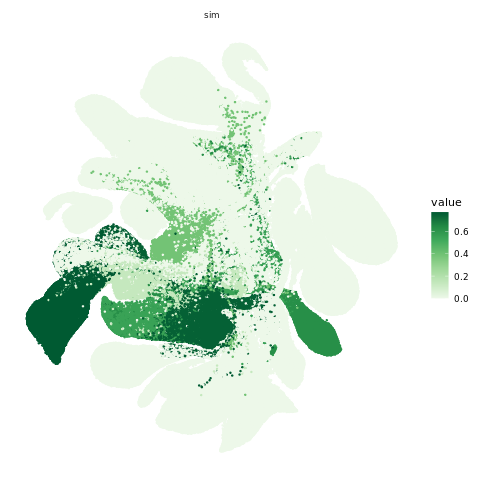

In [83]:
%%R

load('20240626_d2c_heoca.RData')
cell_embedding <- reducedDim(adata, "UMAP")


ggdat <- melt(cbind(data.frame(list('cell' = adata$level_2, 'sim'=ct_sims[as.character(adata$level_2)])), cell_embedding), id.vars = c('1','2', 'cell'))


colnames(ggdat)[1:2] <- paste0('umap',colnames(ggdat)[1:2])
print(head(ggdat))
print(head(ggdat[ggdat$cell == 'club cells',]))

ggdat$value[is.na(ggdat$value)] <- 0

ggplot(ggdat, aes(x=umap1, y = umap2, color = value, group=cell)) + 
geom_point(size =0.5) + facet_wrap(.~variable, scales = 'free') +
theme_minimal() + theme(panel.border = element_blank(), panel.grid.major = element_blank(),
panel.grid.minor = element_blank(), axis.line = element_blank(), axis.text.x=element_blank(), 
axis.title.x=element_blank(), axis.title.y=element_blank(),
axis.text.y=element_blank()) + scale_color_distiller(palette="Greens", direction= 1) +
guides(fill=guide_legend(title="Cosine Similarity \n(tissue-organoid celltype pairs)"))

In [85]:
%%R
save(ggdat, file="cosinesimdata_heoca_ismb2025.RData")

In [59]:
%%R
save(input_list, file='upsetr_plot_input_ismb2025.RData')